In [2]:
import sys
print(sys.executable)

c:\Users\indra\OneDrive\Desktop\zepto_capstone\.venv\Scripts\python.exe


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [5]:
import pandas as pd

df = pd.read_csv("analytics/titanic.csv")

print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
X = df[
    [
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "embarked"
    ]
]

y = df["survived"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked'], dtype='str')

Target:
survived


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [8]:
numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch"
]

categorical_features = [
    "sex",
    "embarked",
    "pclass"
]

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [10]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [11]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [12]:
print("Logistic Regression")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_log))


Logistic Regression
-------------------
Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977
ROC-AUC  : 0.8426877470355731


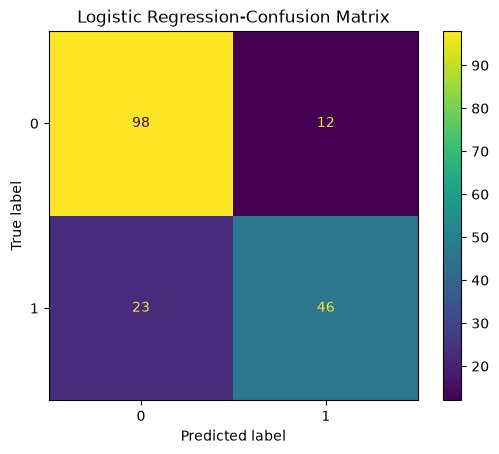

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_log)
plt.title("Logistic Regression-Confusion Matrix")
plt.show()

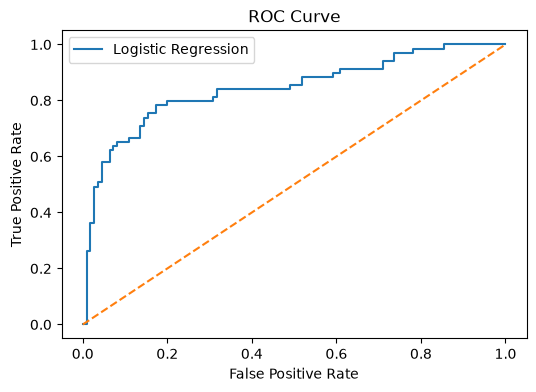

In [14]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob_log)
plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label="Logistic Regression")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [16]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train_processed, y_train)

tree_pred = tree_model.predict(X_test_processed)
tree_prob = tree_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall   :", recall_score(y_test, tree_pred))
print("F1 Score :", f1_score(y_test, tree_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tree_prob))

Decision Tree
Accuracy : 0.7597765363128491
Precision: 0.7407407407407407
Recall   : 0.5797101449275363
F1 Score : 0.6504065040650406
ROC-AUC  : 0.7891304347826088


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Random Forest
Accuracy : 0.8100558659217877
Precision: 0.7868852459016393
Recall   : 0.6956521739130435
F1 Score : 0.7384615384615385
ROC-AUC  : 0.8401844532279314


In [18]:
results=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,tree_pred),
        accuracy_score(y_test,rf_pred)
    ],
    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,tree_pred),
        precision_score(y_test,rf_pred)
    ],
    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,tree_pred),
        recall_score(y_test,rf_pred)
    ],
    "F1":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,tree_pred),
        f1_score(y_test,rf_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test,y_prob_log),
        roc_auc_score(y_test,tree_prob),
        roc_auc_score(y_test,rf_prob)
    ]
    
})
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
1,Decision Tree,0.759777,0.740741,0.579710,0.650407,0.789130
2,Random Forest,0.810056,0.786885,0.695652,0.738462,0.840184


In [19]:
balanced_log = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_log.fit(X_train_processed, y_train)

balanced_log_pred = balanced_log.predict(X_test_processed)
balanced_log_prob = balanced_log.predict_proba(X_test_processed)[:, 1]

print("Balanced Logistic Regression")
print("Accuracy :", accuracy_score(y_test, balanced_log_pred))
print("Precision:", precision_score(y_test, balanced_log_pred))
print("Recall   :", recall_score(y_test, balanced_log_pred))
print("F1 Score :", f1_score(y_test, balanced_log_pred))
print("ROC-AUC  :", roc_auc_score(y_test, balanced_log_prob))

Balanced Logistic Regression
Accuracy : 0.8100558659217877
Precision: 0.7397260273972602
Recall   : 0.782608695652174
F1 Score : 0.7605633802816901
ROC-AUC  : 0.8463768115942029


In [20]:
balanced_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    class_weight="balanced"
)

balanced_tree.fit(X_train_processed, y_train)

balanced_tree_pred = balanced_tree.predict(X_test_processed)
balanced_tree_prob = balanced_tree.predict_proba(X_test_processed)[:, 1]

print("Balanced Decision Tree")
print("Accuracy :", accuracy_score(y_test, balanced_tree_pred))
print("Precision:", precision_score(y_test, balanced_tree_pred))
print("Recall   :", recall_score(y_test, balanced_tree_pred))
print("F1 Score :", f1_score(y_test, balanced_tree_pred))
print("ROC-AUC  :", roc_auc_score(y_test, balanced_tree_prob))

Balanced Decision Tree
Accuracy : 0.770949720670391
Precision: 0.7258064516129032
Recall   : 0.6521739130434783
F1 Score : 0.6870229007633588
ROC-AUC  : 0.8059947299077734


In [21]:
balanced_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

balanced_rf.fit(X_train_processed, y_train)

balanced_rf_pred = balanced_rf.predict(X_test_processed)
balanced_rf_prob = balanced_rf.predict_proba(X_test_processed)[:, 1]

print("Balanced Random Forest")
print("Accuracy :", accuracy_score(y_test, balanced_rf_pred))
print("Precision:", precision_score(y_test, balanced_rf_pred))
print("Recall   :", recall_score(y_test, balanced_rf_pred))
print("F1 Score :", f1_score(y_test, balanced_rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, balanced_rf_prob))

Balanced Random Forest
Accuracy : 0.7932960893854749
Precision: 0.7424242424242424
Recall   : 0.7101449275362319
F1 Score : 0.725925925925926
ROC-AUC  : 0.8260210803689066


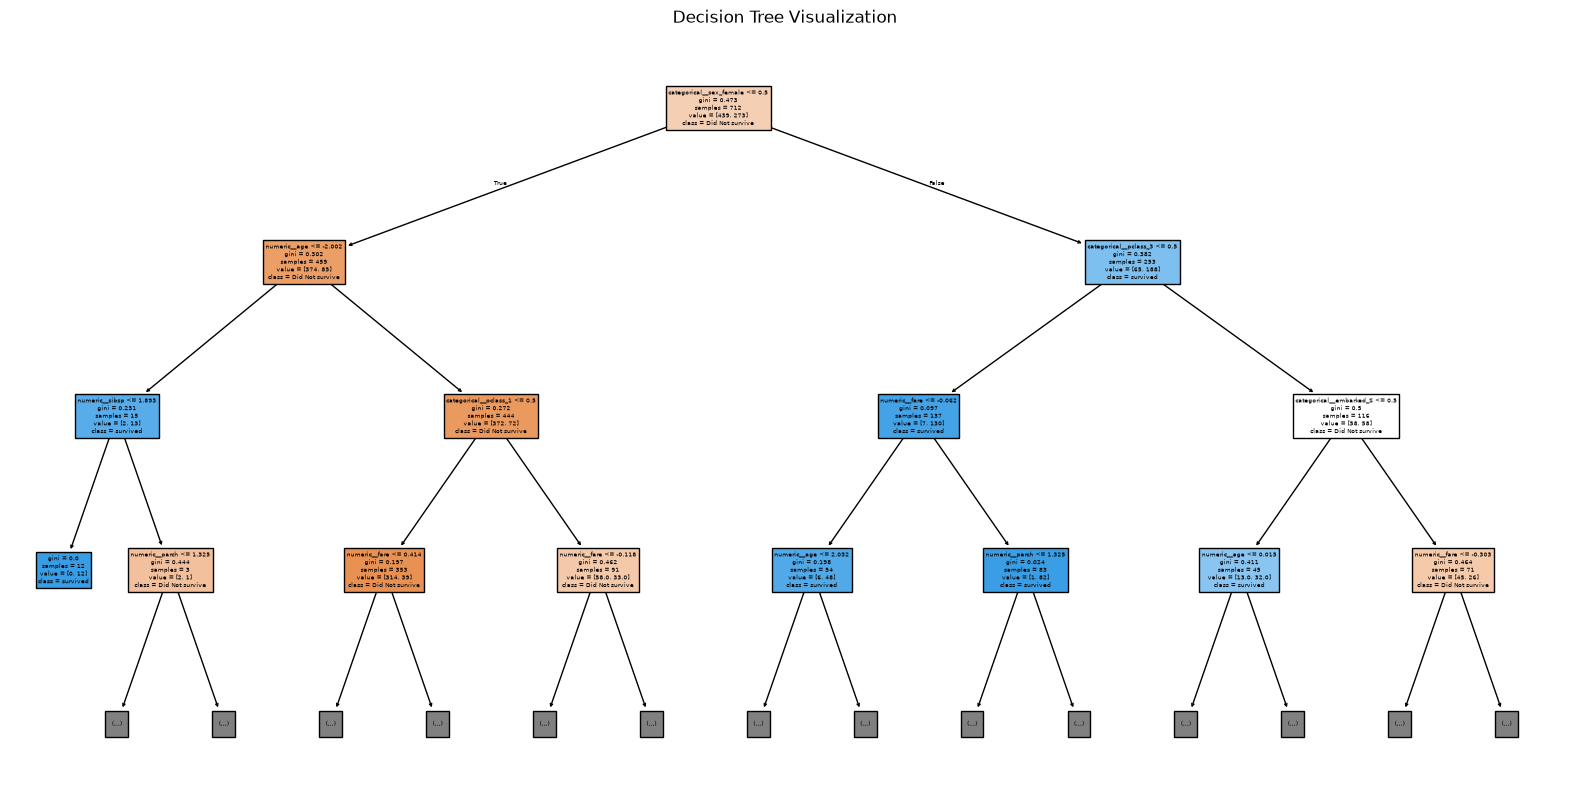

In [22]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["Did Not survive","survived"],
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.show()

In [23]:
balanced_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Balanced Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, balanced_log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, balanced_tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, balanced_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, balanced_log_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, balanced_tree_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, balanced_rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, balanced_log_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, balanced_tree_pred),
        recall_score(y_test, balanced_rf_pred),
        recall_score(y_test,balanced_rf_pred)
        
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, balanced_log_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, balanced_tree_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, balanced_rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, balanced_log_prob),
        roc_auc_score(y_test, tree_prob),
        roc_auc_score(y_test, balanced_tree_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, balanced_rf_prob)
    ]
})

balanced_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
1,Balanced Logistic Regression,0.810056,0.739726,0.782609,0.760563,0.846377
2,Decision Tree,0.759777,0.740741,0.579710,0.650407,0.789130
3,Balanced Decision Tree,0.770950,0.725806,0.652174,0.687023,0.805995
4,Random Forest,0.810056,0.786885,0.710145,0.738462,0.840184
5,Balanced Random Forest,0.793296,0.742424,0.710145,0.725926,0.826021


In [24]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train_processed,y_train)
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
survived
0    439
1    273
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [25]:
smote_log = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_log.fit(X_train_smote, y_train_smote)

smote_log_pred = smote_log.predict(X_test_processed)
smote_log_prob = smote_log.predict_proba(X_test_processed)[:, 1]

print("SMOTE Logistic Regression")
print("Accuracy :", accuracy_score(y_test, smote_log_pred))
print("Precision:", precision_score(y_test, smote_log_pred))
print("Recall   :", recall_score(y_test, smote_log_pred))
print("F1 Score :", f1_score(y_test, smote_log_pred))
print("ROC-AUC  :", roc_auc_score(y_test, smote_log_prob))

SMOTE Logistic Regression
Accuracy : 0.8044692737430168
Precision: 0.7297297297297297
Recall   : 0.782608695652174
F1 Score : 0.7552447552447552
ROC-AUC  : 0.8408432147562582


In [26]:
smote_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

smote_tree.fit(X_train_smote, y_train_smote)

smote_tree_pred = smote_tree.predict(X_test_processed)
smote_tree_prob = smote_tree.predict_proba(X_test_processed)[:, 1]

print("SMOTE Decision Tree")
print("Accuracy :", accuracy_score(y_test, smote_tree_pred))
print("Precision:", precision_score(y_test, smote_tree_pred))
print("Recall   :", recall_score(y_test, smote_tree_pred))
print("F1 Score :", f1_score(y_test, smote_tree_pred))
print("ROC-AUC  :", roc_auc_score(y_test, smote_tree_prob))

SMOTE Decision Tree
Accuracy : 0.7988826815642458
Precision: 0.7142857142857143
Recall   : 0.7971014492753623
F1 Score : 0.7534246575342466
ROC-AUC  : 0.8445981554677205


In [27]:
smote_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

smote_rf.fit(X_train_smote, y_train_smote)

smote_rf_pred = smote_rf.predict(X_test_processed)
smote_rf_prob = smote_rf.predict_proba(X_test_processed)[:, 1]

print("SMOTE Random Forest")
print("Accuracy :", accuracy_score(y_test, smote_rf_pred))
print("Precision:", precision_score(y_test, smote_rf_pred))
print("Recall   :", recall_score(y_test, smote_rf_pred))
print("F1 Score :", f1_score(y_test, smote_rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, smote_rf_prob))

SMOTE Random Forest
Accuracy : 0.8100558659217877
Precision: 0.7536231884057971
Recall   : 0.7536231884057971
F1 Score : 0.7536231884057971
ROC-AUC  : 0.8298418972332017


In [28]:
smote_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "SMOTE Logistic Regression",
        "Decision Tree",
        "Balanced Decision Tree",
        "SMOTE Decision Tree",
        "Random Forest",
        "Balanced Random Forest",
        "SMOTE Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, balanced_log_pred),
        accuracy_score(y_test, smote_log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, balanced_tree_pred),
        accuracy_score(y_test, smote_tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, balanced_rf_pred),
        accuracy_score(y_test, smote_rf_pred)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, balanced_log_pred),
        precision_score(y_test, smote_log_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, balanced_tree_pred),
        precision_score(y_test, smote_tree_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, balanced_rf_pred),
        precision_score(y_test, smote_rf_pred)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, balanced_log_pred),
        recall_score(y_test, smote_log_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, balanced_tree_pred),
        recall_score(y_test, smote_tree_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, balanced_rf_pred),
        recall_score(y_test, smote_rf_pred)
    ],
    
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, balanced_log_pred),
        f1_score(y_test, smote_log_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, balanced_tree_pred),
        f1_score(y_test, smote_tree_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, balanced_rf_pred),
        f1_score(y_test, smote_rf_pred)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, balanced_log_prob),
        roc_auc_score(y_test, smote_log_prob),
        roc_auc_score(y_test, tree_prob),
        roc_auc_score(y_test, balanced_tree_prob),
        roc_auc_score(y_test, smote_tree_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, balanced_rf_prob),
        roc_auc_score(y_test, smote_rf_prob)
    ]
})

smote_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
1,Balanced Logistic Regression,0.810056,0.739726,0.782609,0.760563,0.846377
2,SMOTE Logistic Regression,0.804469,0.729730,0.782609,0.755245,0.840843
3,Decision Tree,0.759777,0.740741,0.579710,0.650407,0.789130
4,Balanced Decision Tree,0.770950,0.725806,0.652174,0.687023,0.805995
5,SMOTE Decision Tree,0.798883,0.714286,0.797101,0.753425,0.844598
6,Random Forest,0.810056,0.786885,0.695652,0.738462,0.840184
7,Balanced Random Forest,0.793296,0.742424,0.710145,0.725926,0.826021
8,SMOTE Random Forest,0.810056,0.753623,0.753623,0.753623,0.829842


In [29]:
from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}

Best CV F1 Score:
0.7473681182704597


In [30]:
best_rf = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42,
    oob_score=True
)

best_rf.fit(X_train_processed, y_train)

print("OOB Score:", best_rf.oob_score_)

OOB Score: 0.824438202247191


In [31]:
best_rf_pred = best_rf.predict(X_test_processed)
best_rf_prob = best_rf.predict_proba(X_test_processed)[:, 1]

print("Final Tuned Random Forest")
print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1 Score :", f1_score(y_test, best_rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, best_rf_prob))

Final Tuned Random Forest
Accuracy : 0.8100558659217877
Precision: 0.8723404255319149
Recall   : 0.5942028985507246
F1 Score : 0.7068965517241379
ROC-AUC  : 0.8401844532279314


In [32]:
from sklearn.model_selection import train_test_split

reg_df = df[
    ["fare", "pclass", "age", "sibsp", "parch", "sex", "embarked"]
].copy()

reg_df = reg_df.dropna()

X_reg = reg_df.drop("fare", axis=1)
y_reg = reg_df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_reg_train.shape)
print("Testing shape :", X_reg_test.shape)

Training shape: (569, 6)
Testing shape : (143, 6)


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features_reg = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_features_reg = [
    "sex",
    "embarked"
]

numeric_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("num", numeric_transformer_reg, numeric_features_reg),
    ("cat", categorical_transformer_reg, categorical_features_reg)
])

In [34]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_reg_train, y_reg_train)

linear_pred = linear_model.predict(X_reg_test)

print("Linear Regression completed!")

Linear Regression completed!


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, linear_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, linear_pred)
)

r2 = r2_score(y_reg_test, linear_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("Linear Regression Results")
print("MAE        :", mae)
print("RMSE       :", rmse)
print("R²         :", r2)
print("Adjusted R²:", adjusted_r2)

Linear Regression Results
MAE        : 24.471123009030467
RMSE       : 60.10399267615684
R²         : 0.30199102009025736
Adjusted R²: 0.2711965062707099


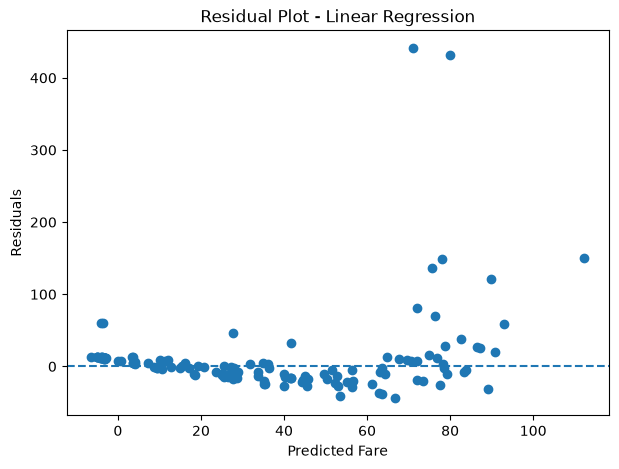

In [36]:
residuals = y_reg_test - linear_pred

plt.figure(figsize=(7, 5))

plt.scatter(linear_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.show()

In [37]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_reg_processed = linear_model.named_steps["preprocessor"].transform(X_reg_test)

X_reg_processed = X_reg_processed.toarray() if hasattr(
    X_reg_processed,
    "toarray"
) else X_reg_processed

X_bp = sm.add_constant(X_reg_processed)

bp_test = het_breuschpagan(
    residuals,
    X_bp
)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(16.151626797279317), 'LM-Test p-value': np.float64(0.06378194913892814), 'F-Statistic': np.float64(2.455653563361066), 'F-Test p-value': np.float64(0.021113492673481466)}


c:\Users\indra\OneDrive\Desktop\zepto_capstone\.venv\Lib\site-packages\statsmodels\stats\diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()


In [38]:
final_classification_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

final_classification_pipeline.fit(X_train, y_train)

print("Final classification pipeline trained!")

Final classification pipeline trained!


In [39]:
import joblib

joblib.dump(
    final_classification_pipeline,
    "analytics/titanic_classification_pipeline.joblib"
)

print("Classification model saved!")

Classification model saved!


In [40]:
loaded_model = joblib.load(
    "analytics/titanic_classification_pipeline.joblib"
)

print("Model loaded successfully!")

Model loaded successfully!


In [42]:
sample_passenger = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [7.25],
    "embarked": ["S"]
})

prediction = loaded_model.predict(sample_passenger)

print("Prediction:", prediction[0])

Prediction: 0


In [43]:
import joblib

joblib.dump(
    linear_model,
    "analytics/titanic_fare_regression_pipeline.joblib"
)

print("Regression pipeline saved successfully!")

Regression pipeline saved successfully!


In [44]:
import joblib
import pandas as pd

# Load classification model
classification_model = joblib.load(
    "analytics/titanic_classification_pipeline.joblib"
)

# Load regression model
regression_model = joblib.load(
    "analytics/titanic_fare_regression_pipeline.joblib"
)

# Raw passenger data
sample = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [7.25],
    "embarked": ["S"]
})

# Classification
survival_prediction = classification_model.predict(sample)

# Regression
fare_prediction = regression_model.predict(
    sample.drop(columns=["fare"])
)

print("Predicted survival:", survival_prediction[0])
print("Predicted fare:", fare_prediction[0])

Predicted survival: 0
Predicted fare: -3.5349825671443114
